In [1]:
import pandas as pd 
import numpy as np

df_values = pd.read_csv("/kaggle/input/datasets/alexandrabln7/uni-dataset/train_samples.csv", header=None)
df_labels = pd.read_csv("/kaggle/input/datasets/alexandrabln7/uni-dataset/train_labels.csv", header=None)

In [2]:
df_labels.head()

,0
0,8.0
1,4.0
2,5.0
3,7.0
4,2.0


In [3]:
df_values.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.120390,0.323718,0.000034,0.000029,0.492832,0.047880,0.931094,0.000000,0.018634,0.045943,...,0.000078,0.991924,0.000000,0.002282,0.984992,0.991536,0.000133,0.936120,0.351642,0.126884
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000342,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.174209,0.435465,0.737319,0.000000,0.559430,0.000000,0.396687,0.666864,0.561351,...,0.917756,0.989727,0.027454,0.778100,0.025024,0.564567,0.521900,0.873315,0.547711,0.534635
3,0.676849,0.837333,0.000055,0.000210,0.000221,0.624539,0.098614,0.756432,0.736644,0.785873,...,0.039870,0.021393,0.700645,0.108689,0.114870,0.834326,0.000106,0.936926,0.000054,0.709673
4,0.762416,0.000283,0.000398,0.866443,0.000000,0.959211,0.000090,0.132567,0.315940,0.633218,...,0.777510,0.236998,0.420625,0.992142,0.065235,0.000037,0.984635,0.796889,0.800577,0.000919


In [4]:
X = df_values.values
y = df_labels.values.ravel()

In [5]:
y = (y - 1).astype(int)
print('Classes:', np.unique(y))
print('Num classes:', len(np.unique(y)))

Classes: [0 1 2 3 4 5 6 7 8 9]
Num classes: 10


In [6]:
print(df_values.shape)
print(df_labels.shape)

(784, 1000)
(1000, 1)


In [7]:
X = df_values.T
print(X.shape)

(1000, 784)


In [8]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

2026-04-14 19:57:43.420030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776196663.686174      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776196663.766371      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776196664.440947      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776196664.440994      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776196664.440997      16 computation_placer.cc:177] computation placer alr

In [9]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score, confusion_matrix

In [10]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracies = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Sequential([
        Input(shape=(784,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=16,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    conf_matrices.append(confusion_matrix(y_test, y_pred))

2026-04-14 19:58:10.546090: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

ci_lower = mean_acc - 1.645 * (std_acc / np.sqrt(10))
ci_upper = mean_acc + 1.645 * (std_acc / np.sqrt(10))

print("Mean Accuracy:", mean_acc)
print("90% Confidence Interval:", (ci_lower, ci_upper))

Mean Accuracy: 0.9200000000000002
90% Confidence Interval: (np.float64(0.8981766088794616), np.float64(0.9418233911205387))


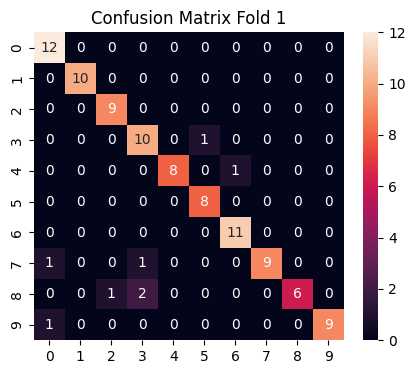

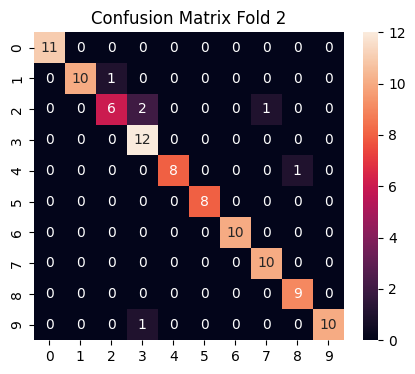

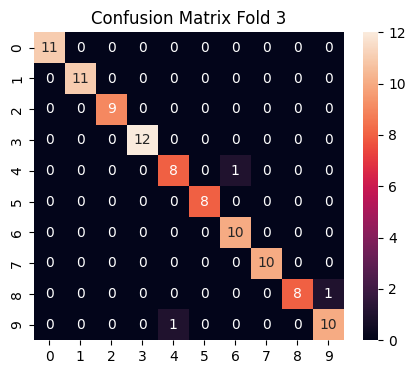

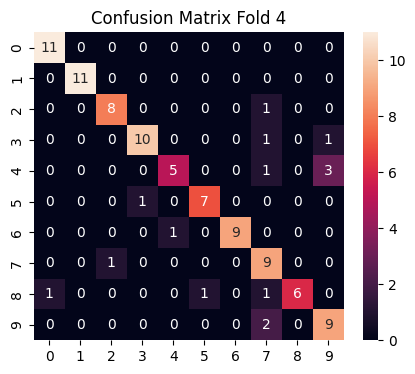

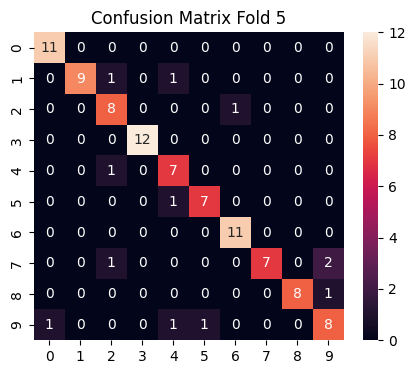

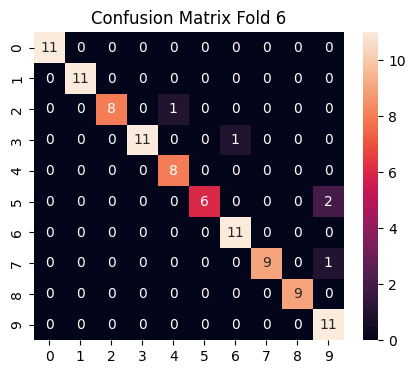

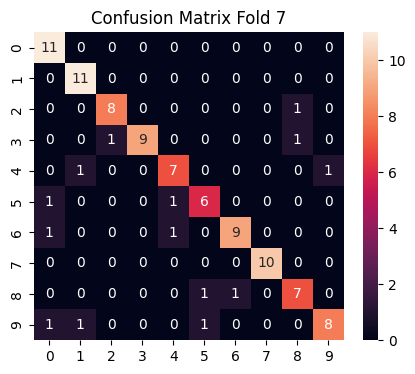

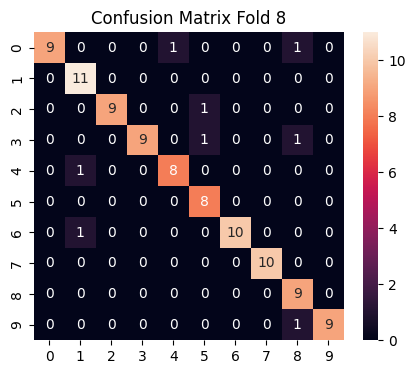

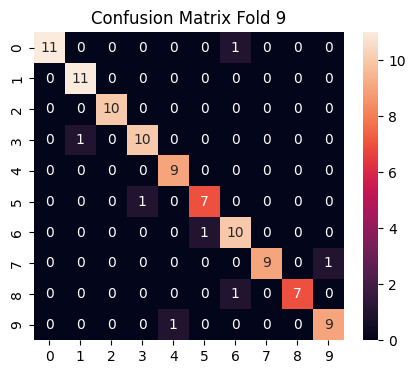

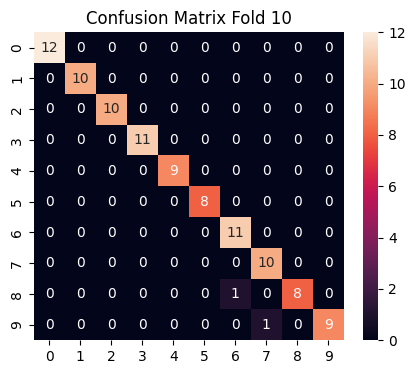

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for i, cm in enumerate(conf_matrices):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix Fold {i+1}')
    plt.show()

In [13]:
df_test = pd.read_csv("/kaggle/input/datasets/alexandrabln7/uni-dataset/test_samples.csv", header=None)
X_test = df_test.T
X_test.shape

(5000, 784)

In [14]:
final_model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.fit(
    X, y,
    epochs=80,
    batch_size=16,
    verbose=0
)

In [15]:
pred_probs = final_model.predict(X_test, verbose=0)
preds = np.argmax(pred_probs, axis=1)
preds = preds + 1

In [16]:
submission = pd.DataFrame({
    "Id": np.arange(1, len(preds) + 1),
    "Prediction": preds
})

submission.to_csv("submission.csv", index=False)